<a href="https://colab.research.google.com/github/Hannnann/early_cancer_detection/blob/main/brain_tumor_detection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early Brain Tumor Detection Using Image Processing and Classical Machine Learning Algorithms

**Google Colab Notebook — RAM-Safe Version**

This notebook supports a dissertation workflow for brain tumor MRI classification using image preprocessing, handcrafted feature extraction, classical machine learning models, and a lightweight CNN baseline.

Models included:
- Support Vector Machine (SVM)
- Random Forest
- Logistic Regression
- k-Nearest Neighbours (k-NN)
- CNN baseline

Key outputs:
- Accuracy, precision, recall/sensitivity, F1-score, ROC-AUC
- Confusion matrices
- Training and inference time
- Cross-validation
- SHAP and LIME interpretability


In [ ]:
# Install required libraries
!pip install opencv-python scikit-image imbalanced-learn lime shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Import libraries
import os
import cv2
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import label, regionprops
from skimage.filters import threshold_otsu
from skimage.morphology import closing, square

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Path

Update the path below if your dataset folder is named differently.

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/dissertation/dataset-brain-tumor/Training"

IMG_SIZE = 128
BATCH_SIZE = 16
RANDOM_STATE = 42

print('Dataset path:', DATASET_PATH)
print('Image size:', IMG_SIZE)

Dataset path: /content/drive/MyDrive/dissertation/dataset-brain-tumor/Training
Image size: 128


In [ ]:
# Check dataset classes
class_names = []

for item in os.listdir(DATASET_PATH):
    item_path = os.path.join(DATASET_PATH, item)
    if os.path.isdir(item_path):
        class_names.append(item)

class_names = sorted(class_names)
print('Classes found:', class_names)

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    valid_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(cls, ':', len(valid_files), 'images')

Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
glioma : 1400 images
meningioma : 1400 images
notumor : 1400 images
pituitary : 1400 images


# Part A: Classical Machine Learning Pipeline

In [ ]:
def preprocess_image(image, img_size=128):
    image = cv2.resize(image, (img_size, img_size))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Noise reduction
    denoised = cv2.medianBlur(gray, 3)

    # Contrast enhancement using CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    # Normalize
    normalized = enhanced / 255.0
    return normalized

def segment_image(preprocessed_img):
    img_uint8 = (preprocessed_img * 255).astype(np.uint8)

    try:
        thresh = threshold_otsu(img_uint8)
        binary = img_uint8 > thresh
    except Exception:
        binary = img_uint8 > 100

    cleaned = closing(binary, square(3))
    return cleaned.astype(np.uint8)

In [ ]:
def extract_features(image):
    preprocessed = preprocess_image(image, IMG_SIZE)
    img_uint8 = (preprocessed * 255).astype(np.uint8)

    features = []

    # GLCM texture features
    glcm = graycomatrix(
        img_uint8, distances=[1], angles=[0], levels=256,
        symmetric=True, normed=True
    )
    features.extend([
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0]
    ])

    # Statistical features
    mean_intensity = np.mean(img_uint8)
    std_intensity = np.std(img_uint8)
    variance = np.var(img_uint8)

    hist = cv2.calcHist([img_uint8], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)
    entropy = -np.sum(hist * np.log2(hist + 1e-10))
    features.extend([mean_intensity, std_intensity, variance, entropy])

    # Edge feature
    edges = cv2.Canny(img_uint8, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    features.append(edge_density)

    # Shape features
    segmented = segment_image(preprocessed)
    labelled = label(segmented)
    regions = regionprops(labelled)

    if len(regions) > 0:
        largest_region = max(regions, key=lambda r: r.area)
        area = largest_region.area
        perimeter = largest_region.perimeter
        eccentricity = largest_region.eccentricity
        solidity = largest_region.solidity
    else:
        area, perimeter, eccentricity, solidity = 0, 0, 0, 0

    features.extend([area, perimeter, eccentricity, solidity])
    return features

In [ ]:
# Extract features directly from images without storing all images in RAM
features_list = []
labels_list = []

start_time = time.time()

for class_name in class_names:
    class_folder = os.path.join(DATASET_PATH, class_name)
    valid_files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for idx, file_name in enumerate(valid_files):
        file_path = os.path.join(class_folder, file_name)
        img = cv2.imread(file_path)

        if img is None:
            continue

        try:
            features = extract_features(img)
            features_list.append(features)
            labels_list.append(class_name)
        except Exception as e:
            print('Error processing:', file_path, e)

        if idx % 500 == 0:
            print(f'Processing class {class_name}: {idx} images done')

end_time = time.time()

X = np.array(features_list)
y = np.array(labels_list)

print('Feature extraction completed.')
print('Total samples:', X.shape[0])
print('Feature shape:', X.shape)
print('Time taken:', round(end_time - start_time, 2), 'seconds')

Processing class glioma: 0 images done
Processing class glioma: 500 images done
Processing class glioma: 1000 images done
Processing class meningioma: 0 images done
Processing class meningioma: 500 images done
Processing class meningioma: 1000 images done
Processing class notumor: 0 images done
Processing class notumor: 500 images done
Processing class notumor: 1000 images done
Processing class pituitary: 0 images done
Processing class pituitary: 500 images done
Processing class pituitary: 1000 images done
Feature extraction completed.
Total samples: 5600
Feature shape: (5600, 13)
Time taken: 273.47 seconds


In [ ]:
feature_names = [
    'GLCM_Contrast', 'GLCM_Homogeneity', 'GLCM_Energy', 'GLCM_Correlation',
    'Mean_Intensity', 'Std_Intensity', 'Variance', 'Entropy',
    'Edge_Density', 'Area', 'Perimeter', 'Eccentricity', 'Solidity'
]

df_features = pd.DataFrame(X, columns=feature_names)
df_features['Label'] = y
df_features.head()

,GLCM_Contrast,GLCM_Homogeneity,GLCM_Energy,GLCM_Correlation,Mean_Intensity,Std_Intensity,Variance,Entropy,Edge_Density,Area,Perimeter,Eccentricity,Solidity,Label
0,308.499385,0.679852,0.332556,0.948158,38.705078,54.425763,2962.163631,4.795298,0.056213,4888.0,411.646753,0.462188,0.950049,glioma
1,288.812623,0.582106,0.248957,0.946772,42.802979,52.002462,2704.256104,5.596138,0.093689,5681.0,690.949314,0.692742,0.884615,glioma
2,516.698696,0.383653,0.081304,0.936807,75.622192,63.982433,4093.751793,7.035929,0.123352,8160.0,1257.915872,0.533084,0.806643,glioma
3,463.781250,0.487638,0.221088,0.940662,62.110962,62.489730,3904.966325,6.233157,0.116882,7400.0,834.375721,0.600264,0.878964,glioma
4,396.744464,0.372965,0.067676,0.919244,65.089478,49.641146,2464.243337,6.870593,0.138123,9611.0,935.186904,0.565791,0.867575,glioma


glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64


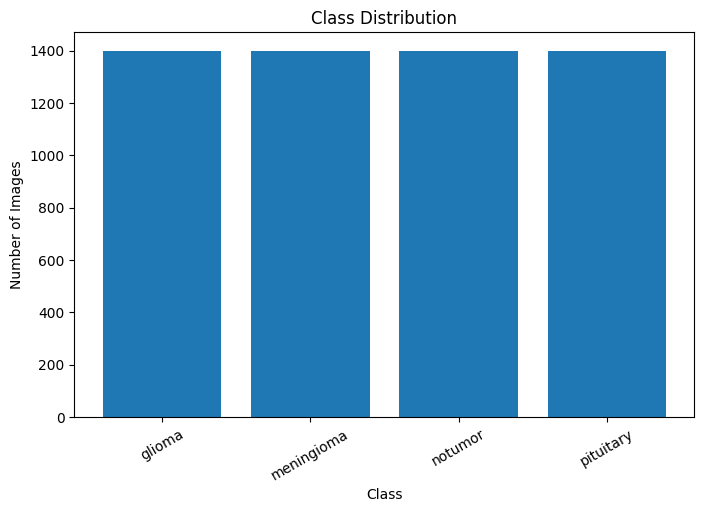

In [ ]:
label_counts = pd.Series(y).value_counts()
print(label_counts)

plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)
plt.show()

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Encoded classes:')
for i, class_name in enumerate(label_encoder.classes_):
    print(i, '=', class_name)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Encoded classes:
0 = glioma
1 = meningioma
2 = notumor
3 = pituitary
Training samples: 4480
Testing samples: 1120


In [ ]:
# Apply SMOTE only to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:')
print(pd.Series(y_train).value_counts())
print('\nAfter SMOTE:')
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
3    1120
2    1120
0    1120
1    1120
Name: count, dtype: int64

After SMOTE:
3    1120
2    1120
0    1120
1    1120
Name: count, dtype: int64


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print('\n' + '=' * 70)
    print(model_name)
    print('=' * 70)

    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()
    training_time = end_train - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    end_pred = time.time()
    inference_time = ((end_pred - start_pred) / len(X_test)) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test)
            y_test_bin = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
            roc_auc = roc_auc_score(y_test_bin, y_score, average='weighted', multi_class='ovr')
        else:
            roc_auc = None
    except Exception:
        roc_auc = None

    print('Accuracy:', round(accuracy * 100, 2), '%')
    print('Precision:', round(precision, 4))
    print('Recall / Sensitivity:', round(recall, 4))
    print('F1-Score:', round(f1, 4))
    print('ROC-AUC:', round(roc_auc, 4) if roc_auc is not None else 'N/A')
    print('Training Time:', round(training_time, 4), 'seconds')
    print('Inference Time:', round(inference_time, 4), 'ms/image')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time': training_time,
        'Inference Time': inference_time,
        'Confusion Matrix': cm,
        'Predictions': y_pred,
        'Model Object': model
    }

In [ ]:
# Train classical models
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
rf_model = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=RANDOM_STATE, n_jobs=-1)
lr_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

svm_results = evaluate_model(svm_model, X_train_balanced, y_train_balanced, X_test_scaled, y_test, 'Support Vector Machine')
rf_results = evaluate_model(rf_model, X_train_balanced, y_train_balanced, X_test_scaled, y_test, 'Random Forest')
lr_results = evaluate_model(lr_model, X_train_balanced, y_train_balanced, X_test_scaled, y_test, 'Logistic Regression')
knn_results = evaluate_model(knn_model, X_train_balanced, y_train_balanced, X_test_scaled, y_test, 'k-Nearest Neighbours')


Support Vector Machine
Accuracy: 84.11 %
Precision: 0.8448
Recall / Sensitivity: 0.8411
F1-Score: 0.84
ROC-AUC: 0.9542
Training Time: 2.4775 seconds
Inference Time: 0.1517 ms/image

Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.72      0.80       280
  meningioma       0.73      0.78      0.76       280
     notumor       0.89      0.94      0.91       280
   pituitary       0.86      0.91      0.89       280

    accuracy                           0.84      1120
   macro avg       0.84      0.84      0.84      1120
weighted avg       0.84      0.84      0.84      1120


Random Forest
Accuracy: 88.48 %
Precision: 0.8854
Recall / Sensitivity: 0.8848
F1-Score: 0.8842
ROC-AUC: 0.9796
Training Time: 1.4427 seconds
Inference Time: 0.0399 ms/image

Classification Report:
              precision    recall  f1-score   support

      glioma       0.91      0.81      0.86       280
  meningioma       0.80      0.82      0.81       2

# Part B: CNN Baseline Using Batch Loading

In [ ]:
# Clear memory before CNN
gc.collect()
tf.keras.backend.clear_session()

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset='training', seed=RANDOM_STATE,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset='validation', seed=RANDOM_STATE,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

cnn_class_names = train_ds.class_names
num_classes = len(cnn_class_names)

print('CNN classes:', cnn_class_names)
print('Number of classes:', num_classes)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
CNN classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


In [ ]:
# Normalize and prefetch without cache to save RAM
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
cnn_model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,724 (3.15 MB)

 Trainable params: 826,724 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start_train = time.time()
history = cnn_model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop], verbose=1)
end_train = time.time()

cnn_training_time = end_train - start_train
print('CNN Training Time:', round(cnn_training_time, 2), 'seconds')

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 102s 243ms/step - accuracy: 0.6629 - loss: 0.7788 - val_accuracy: 0.8438 - val_loss: 0.4755
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 89s 243ms/step - accuracy: 0.8181 - loss: 0.4696 - val_accuracy: 0.8723 - val_loss: 0.3507
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 145s 246ms/step - accuracy: 0.8665 - loss: 0.3453 - val_accuracy: 0.9116 - val_loss: 0.2674
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 92s 255ms/step - accuracy: 0.9016 - loss: 0.2571 - val_accuracy: 0.9125 - val_loss: 0.2465
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 142s 256ms/step - accuracy: 0.9237 - loss: 0.2020 - val_accuracy: 0.8866 - val_loss: 0.3121
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 141s 255ms/step - accuracy: 0.9355 - loss: 0.1681 - val_accuracy: 0.9259 - val_loss: 0.2181
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 141s 253ms/step - accuracy: 0.9556 - loss: 0.1224 - val_accuracy: 0.9411 - val_loss: 0.1992
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 91s 252ms/step - accuracy: 0.9525 - lo

In [ ]:
y_true_cnn = []
y_pred_cnn = []
y_prob_cnn = []

start_pred = time.time()

for batch_images, batch_labels in val_ds:
    probs = cnn_model.predict(batch_images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true_cnn.extend(batch_labels.numpy())
    y_pred_cnn.extend(preds)
    y_prob_cnn.extend(probs)

end_pred = time.time()

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)
y_prob_cnn = np.array(y_prob_cnn)

cnn_inference_time = ((end_pred - start_pred) / len(y_true_cnn)) * 1000
cnn_accuracy = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_precision = precision_score(y_true_cnn, y_pred_cnn, average='weighted')
cnn_recall = recall_score(y_true_cnn, y_pred_cnn, average='weighted')
cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='weighted')
cnn_cm = confusion_matrix(y_true_cnn, y_pred_cnn)

try:
    y_true_bin_cnn = label_binarize(y_true_cnn, classes=np.arange(num_classes))
    cnn_roc_auc = roc_auc_score(y_true_bin_cnn, y_prob_cnn, average='weighted', multi_class='ovr')
except Exception:
    cnn_roc_auc = None

print('CNN Accuracy:', round(cnn_accuracy * 100, 2), '%')
print('CNN Precision:', round(cnn_precision, 4))
print('CNN Recall / Sensitivity:', round(cnn_recall, 4))
print('CNN F1-Score:', round(cnn_f1, 4))
print('CNN ROC-AUC:', round(cnn_roc_auc, 4) if cnn_roc_auc is not None else 'N/A')
print('CNN Inference Time:', round(cnn_inference_time, 4), 'ms/image')
print('\nClassification Report:')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=cnn_class_names))

CNN Accuracy: 93.93 %
CNN Precision: 0.9409
CNN Recall / Sensitivity: 0.9393
CNN F1-Score: 0.9381
CNN ROC-AUC: 0.9934
CNN Inference Time: 13.0449 ms/image

Classification Report:
              precision    recall  f1-score   support

      glioma       0.88      0.97      0.92       260
  meningioma       0.95      0.81      0.88       275
     notumor       0.98      0.98      0.98       300
   pituitary       0.94      0.99      0.97       285

    accuracy                           0.94      1120
   macro avg       0.94      0.94      0.94      1120
weighted avg       0.94      0.94      0.94      1120



# Part C: Results Tables and Visualizations

In [ ]:
all_results = [svm_results, rf_results, lr_results, knn_results]
summary_data = []

for result in all_results:
    summary_data.append({
        'Model': result['Model'],
        'Accuracy (%)': round(result['Accuracy'] * 100, 2),
        'Precision': round(result['Precision'], 4),
        'Recall/Sensitivity': round(result['Recall'], 4),
        'F1-Score': round(result['F1-Score'], 4),
        'ROC-AUC': round(result['ROC-AUC'], 4) if result['ROC-AUC'] is not None else 'N/A',
        'Training Time (s)': round(result['Training Time'], 4),
        'Inference Time (ms/image)': round(result['Inference Time'], 4)
    })

summary_data.append({
    'Model': 'CNN Baseline',
    'Accuracy (%)': round(cnn_accuracy * 100, 2),
    'Precision': round(cnn_precision, 4),
    'Recall/Sensitivity': round(cnn_recall, 4),
    'F1-Score': round(cnn_f1, 4),
    'ROC-AUC': round(cnn_roc_auc, 4) if cnn_roc_auc is not None else 'N/A',
    'Training Time (s)': round(cnn_training_time, 4),
    'Inference Time (ms/image)': round(cnn_inference_time, 4)
})

results_df = pd.DataFrame(summary_data)
results_df

,Model,Accuracy (%),Precision,Recall/Sensitivity,F1-Score,ROC-AUC,Training Time (s),Inference Time (ms/image)
0,Support Vector Machine,84.11,0.8448,0.8411,0.8400,0.9542,2.4775,0.1517
1,Random Forest,88.48,0.8854,0.8848,0.8842,0.9796,1.4427,0.0399
2,Logistic Regression,75.27,0.7548,0.7527,0.7530,0.9079,0.0604,0.0004
3,k-Nearest Neighbours,86.79,0.8683,0.8679,0.8674,0.9598,0.0087,0.0359
4,CNN Baseline,93.93,0.9409,0.9393,0.9381,0.9934,1176.7308,13.0449


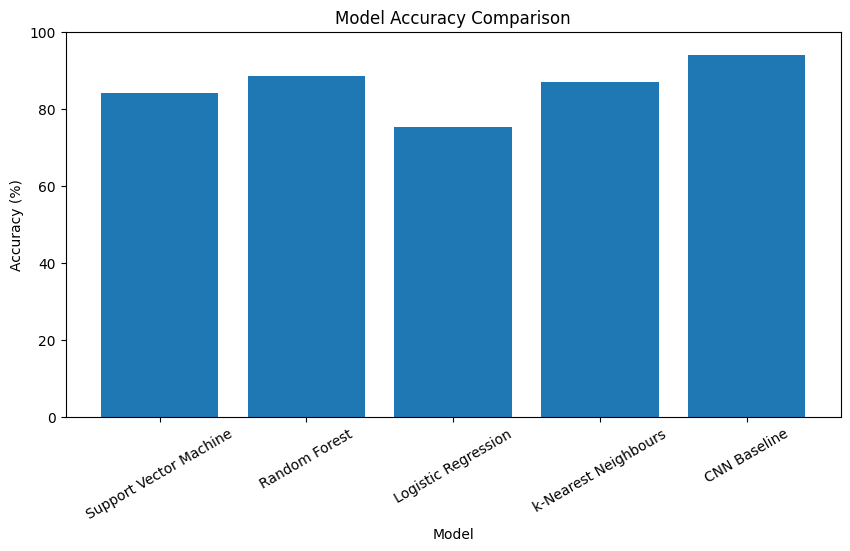

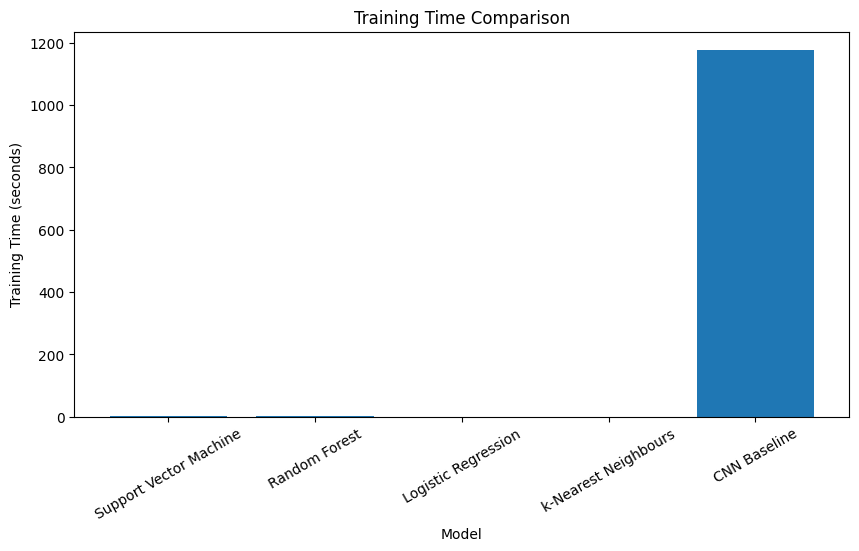

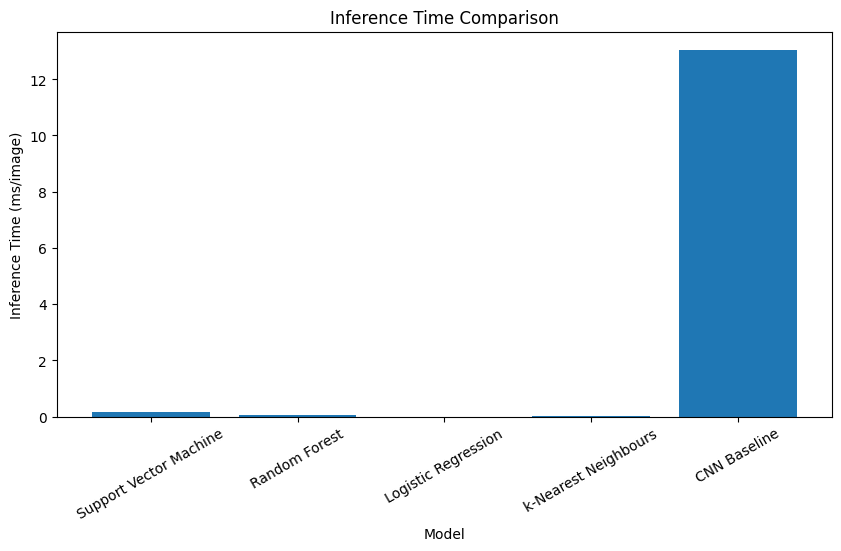

In [ ]:
# Charts
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy (%)'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Training Time (s)'])
plt.title('Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Inference Time (ms/image)'])
plt.title('Inference Time Comparison')
plt.xlabel('Model')
plt.ylabel('Inference Time (ms/image)')
plt.xticks(rotation=30)
plt.show()

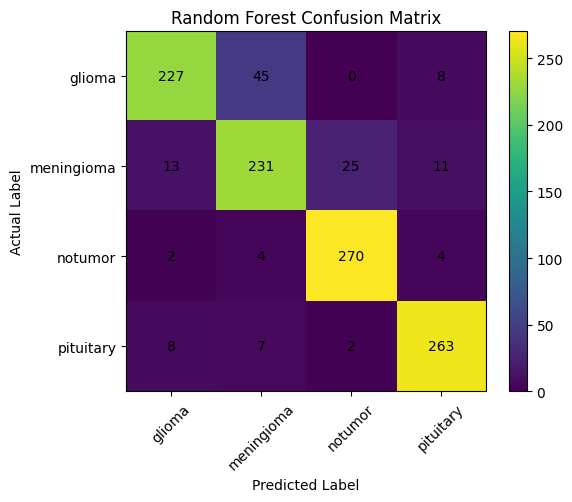

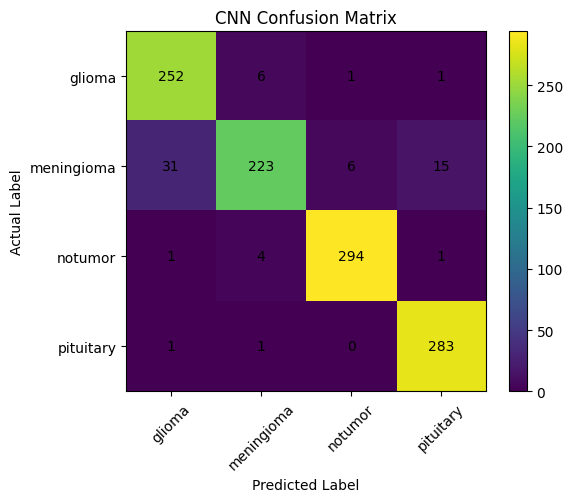

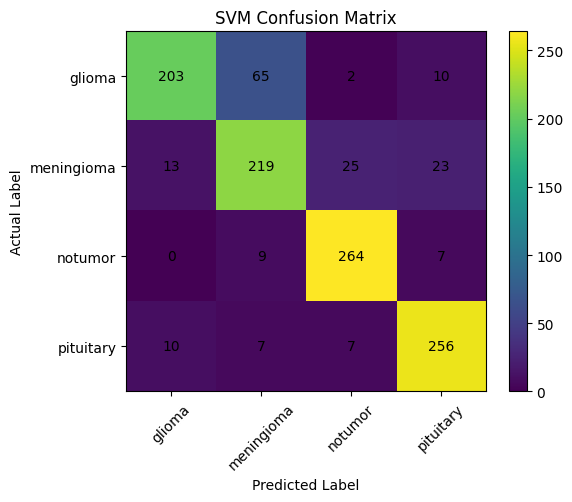

In [ ]:
def plot_confusion_matrix(cm, title, class_labels):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels, rotation=45)
    plt.yticks(tick_marks, class_labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], horizontalalignment='center', verticalalignment='center')

    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(rf_results['Confusion Matrix'], 'Random Forest Confusion Matrix', label_encoder.classes_)
plot_confusion_matrix(cnn_cm, 'CNN Confusion Matrix', cnn_class_names)
plot_confusion_matrix(
    svm_results['Confusion Matrix'],
    'SVM Confusion Matrix',
    label_encoder.classes_
)

# Part D: Cross-Validation

In [ ]:
models_cv = {
    'SVM': svm_model,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model,
    'k-NN': knn_model
}

cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, model in models_cv.items():
    print('Running cross-validation for:', model_name)
    scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model': model_name,
        'Mean CV Accuracy': round(scores.mean(), 4),
        'Standard Deviation': round(scores.std(), 4)
    })

cv_df = pd.DataFrame(cv_results)
cv_df

Running cross-validation for: SVM
Running cross-validation for: Random Forest
Running cross-validation for: Logistic Regression
Running cross-validation for: k-NN


,Model,Mean CV Accuracy,Standard Deviation
0,SVM,0.8246,0.0080
1,Random Forest,0.8839,0.0130
2,Logistic Regression,0.7455,0.0088
3,k-NN,0.8417,0.0121


# Part E: SHAP and LIME Interpretability

These sections use a small sample to avoid RAM crashes.

In [ ]:
import shap

SHAP_SAMPLE_SIZE = 30
X_shap_sample = X_test_scaled[:SHAP_SAMPLE_SIZE]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

print('SHAP values generated successfully.')

SHAP values generated successfully.


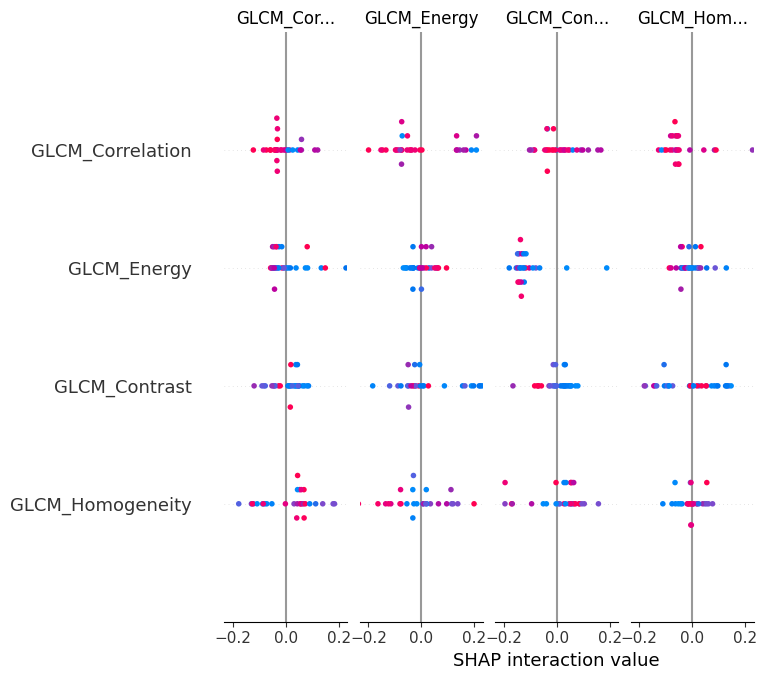

In [ ]:
try:
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0], X_shap_sample, feature_names=feature_names)
    else:
        shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names)
except Exception as e:
    print('SHAP plot error:', e)

In [ ]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_balanced,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    mode='classification'
)

sample_index = 0
lime_exp = lime_explainer.explain_instance(
    X_test_scaled[sample_index],
    rf_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

ROC


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(label_encoder.classes_)

# Binarize test labels
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Classical models probabilities
svm_probs = svm_model.predict_proba(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)
knn_probs = knn_model.predict_proba(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)

# CNN already has probabilities
cnn_probs = y_prob_cnn
y_true_bin_cnn = label_binarize(y_true_cnn, classes=np.arange(n_classes))

In [ ]:
def compute_roc(y_true_bin, y_probs):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_bin.ravel(), y_probs.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    return fpr["micro"], tpr["micro"], roc_auc["micro"]

In [ ]:
svm_fpr, svm_tpr, svm_auc = compute_roc(y_test_bin, svm_probs)
rf_fpr, rf_tpr, rf_auc = compute_roc(y_test_bin, rf_probs)
knn_fpr, knn_tpr, knn_auc = compute_roc(y_test_bin, knn_probs)
lr_fpr, lr_tpr, lr_auc = compute_roc(y_test_bin, lr_probs)

cnn_fpr, cnn_tpr, cnn_auc = compute_roc(y_true_bin_cnn, cnn_probs)

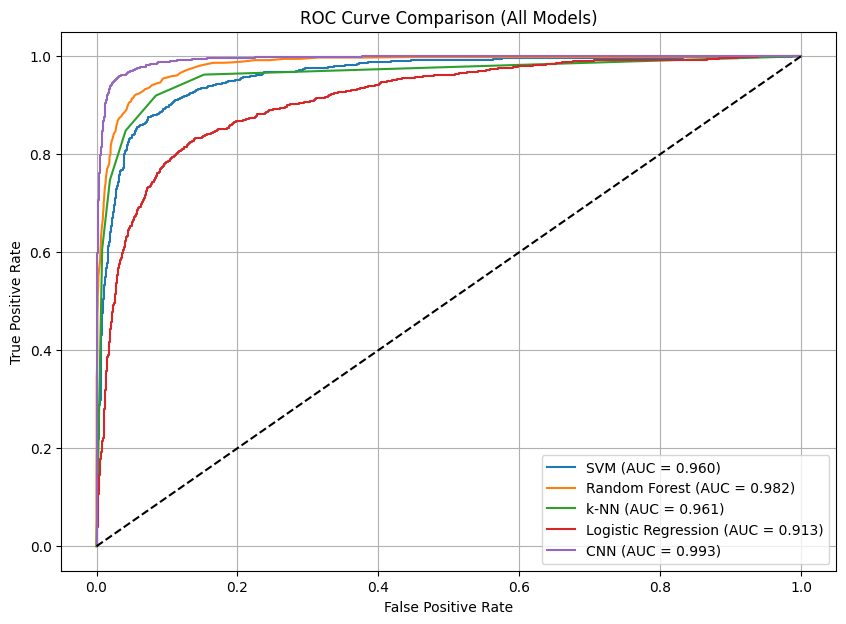

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(knn_fpr, knn_tpr, label=f"k-NN (AUC = {knn_auc:.3f})")
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(cnn_fpr, cnn_tpr, label=f"CNN (AUC = {cnn_auc:.3f})")

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve Comparison (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()

plt.show()

In [ ]:
# ================================
# 5-Fold Cross-Validation for Classical ML Models
# ================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------------------------
# IMPORTANT:
# Replace X and y with your actual feature and label variables.
# Example:
# X = features
# y = labels
# ------------------------------------------------

# If your variables are named differently, update here:
X_cv = X
y_cv = y

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define models
models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])
}

# Run cross-validation
cv_results = {}

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_cv,
        y_cv,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results[model_name] = scores

    print(f"{model_name}")
    print(f"Fold Scores: {scores}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")
    print("-" * 50)

SVM
Fold Scores: [0.81696429 0.81428571 0.83125    0.83660714 0.84553571]
Mean Accuracy: 0.8289
Standard Deviation: 0.0118
--------------------------------------------------
Random Forest
Fold Scores: [0.87053571 0.87946429 0.89375    0.89375    0.89464286]
Mean Accuracy: 0.8864
Standard Deviation: 0.0098
--------------------------------------------------
Logistic Regression
Fold Scores: [0.74107143 0.74375    0.74732143 0.74553571 0.75446429]
Mean Accuracy: 0.7464
Standard Deviation: 0.0045
--------------------------------------------------
k-NN
Fold Scores: [0.85535714 0.84910714 0.86785714 0.86517857 0.87589286]
Mean Accuracy: 0.8627
Standard Deviation: 0.0094
--------------------------------------------------


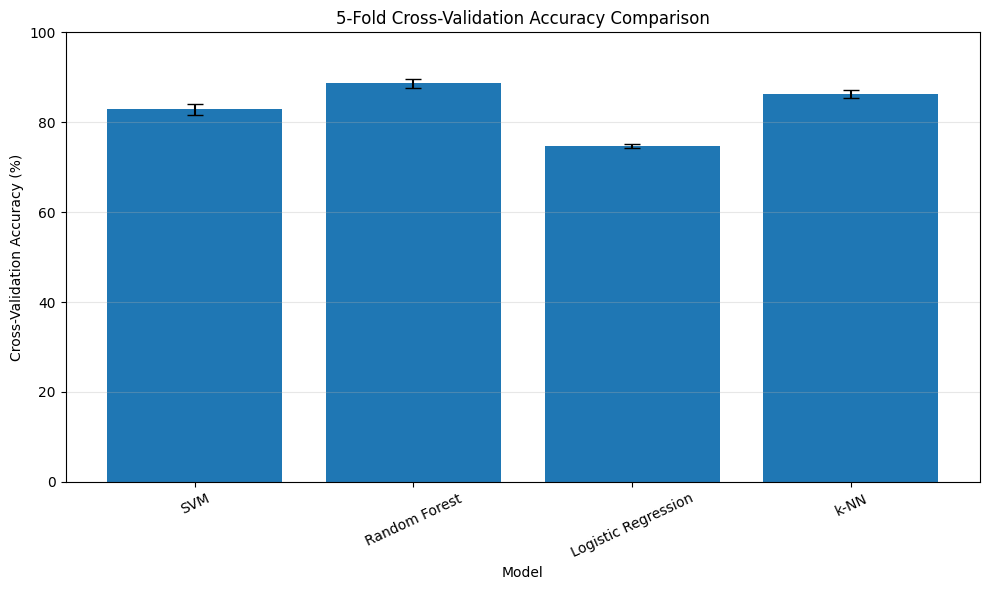

In [ ]:
# ================================
# Cross-Validation Accuracy Chart
# ================================

model_names = list(cv_results.keys())
mean_scores = [cv_results[m].mean() * 100 for m in model_names]
std_scores = [cv_results[m].std() * 100 for m in model_names]

plt.figure(figsize=(10, 6))
plt.bar(model_names, mean_scores, yerr=std_scores, capsize=6)
plt.ylabel("Cross-Validation Accuracy (%)")
plt.xlabel("Model")
plt.title("5-Fold Cross-Validation Accuracy Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("cross_validation_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Part F: Save Results and Models

In [ ]:
results_df.to_csv('model_performance_results.csv', index=False)
cv_df.to_csv('cross_validation_results.csv', index=False)
df_features.to_csv('extracted_features.csv', index=False)

print('CSV files saved successfully.')

CSV files saved successfully.


In [ ]:
import joblib

joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(knn_model, 'knn_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
cnn_model.save('cnn_baseline_model.h5')

print('Models saved successfully.')

Models saved successfully.


In [ ]:
from google.colab import files

files.download('model_performance_results.csv')
files.download('cross_validation_results.csv')
files.download('extracted_features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Dissertation Summary

In [ ]:
best_classical = results_df[results_df['Model'] != 'CNN Baseline'].sort_values(
    by='Accuracy (%)', ascending=False
).iloc[0]

cnn_row = results_df[results_df['Model'] == 'CNN Baseline'].iloc[0]

print('Final Dissertation Summary')
print('=' * 60)
print('Best Classical Model:', best_classical['Model'])
print('Best Classical Accuracy:', best_classical['Accuracy (%)'], '%')
print('CNN Accuracy:', cnn_row['Accuracy (%)'], '%')
print('Best Classical Training Time:', best_classical['Training Time (s)'], 'seconds')
print('CNN Training Time:', cnn_row['Training Time (s)'], 'seconds')
print('Best Classical Inference Time:', best_classical['Inference Time (ms/image)'], 'ms/image')
print('CNN Inference Time:', cnn_row['Inference Time (ms/image)'], 'ms/image')

Final Dissertation Summary
Best Classical Model: Random Forest
Best Classical Accuracy: 88.48 %
CNN Accuracy: 93.84 %
Best Classical Training Time: 3.3213 seconds
CNN Training Time: 1189.3549 seconds
Best Classical Inference Time: 0.0826 ms/image
CNN Inference Time: 17.8454 ms/image


## Dissertation Note

Use the actual results generated by this notebook in your Results and Analysis chapter. Do not force your dissertation values to match example values unless your notebook produces the same results.

Suggested methodology sentence:

> To reduce memory limitations in Google Colab, all images were resized to 128 × 128 pixels. Classical machine learning models were trained using extracted numerical features rather than raw image arrays. The CNN baseline was trained using TensorFlow batch loading to avoid loading the full dataset into memory at once.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/dissertation/brain_tumor_detection_colab (1).ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/dissertation/brain_tumor_detection_colab (1).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 2034471 bytes to /content/drive/MyDrive/dissertation/brain_tumor_detection_colab (1).html
